In [1]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline
import warnings
import matplotlib.pyplot as plt
import sys 
import os 
import pandas as pd
import anndata as ad
import scanpy as sc
import numpy as np
import seaborn as sns
from scipy.stats import linregress
import matplotlib.patches as mpatches
from scipy.stats import pearsonr, spearmanr
plt.rcParams["figure.figsize"]=4,4

warnings.filterwarnings("ignore")

In [2]:
adata = ad.read_h5ad('/vol/projects/CIIM/Healthy_Single_Cell_Data/count_matrix/data12_CMtx.h5ad', backed='r')
# sc.pp.normalize_total(adata)
# sc.pp.log1p(adata)
# sc.pp.highly_variable_genes(adata, n_top_genes=2000)

# sc.pp.pca(adata, use_highly_variable=True)  
# sc.pp.neighbors(adata, n_neighbors=15)  
# sc.tl.umap(adata)  

In [2]:
adata = ad.read_h5ad('/vol/projects/CIIM/Healthy_Single_Cell_Data/count_matrix/data12_CMtx.h5ad', backed='r')


Text(0.5, 1.0, 'Cohort 3')

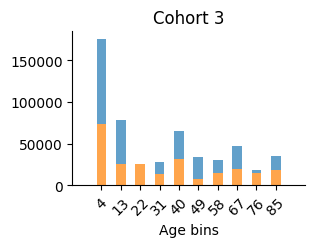

In [8]:
from ciim.src.common import palette_gender, surrogate_names
fig, ax = plt.subplots(1, 1, figsize=(3, 2), sharey=False)

df = adata.obs.copy()
df['sex'] = df['sex'].apply(lambda name: {'F':'Female', 'M':'Male'}.get(name, name))

# Count occurrences of each sex within each age group
df_count = df.groupby(['age', 'sex']).size().reset_index(name='count')

# Pivot data for stacking
df_pivot = df_count.pivot(index='age', columns='sex', values='count').fillna(0)

# Plot stacked bar chart
df_pivot['binned'] = pd.cut(pd.to_numeric(df_pivot.index, errors='coerce'), bins=10)  
df_binned = df_pivot.groupby('binned').sum() 
df_binned.plot(kind='bar', stacked=True, ax=ax, color=palette_gender, alpha=0.7)


ax.set_xlabel("Age bins")
# ax.set_ylabel("Sample (donor-age)" if i == 0 else "")  
# ax.set_title(surrogate_names[dataset], pad=15)
bin_midpoints = [int(interval.mid) for interval in df_binned.index.categories]
ax.set_xticklabels(bin_midpoints)

# Set x-axis ticks
# ax.set_xticks(bin_midpoints)
# Adjust xticks to show fewer labels
# xtick_labels = [int(float(label.get_text())) for label in ]
# step = max(1, len(xtick_labels) // 5)  # Show ~5 evenly spaced labels
# ax.set_xticks(range(0, len(xtick_labels), step))
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
x_min, x_max = ax.get_xlim()
ax.set_xlim(x_min - 1, x_max + 1) 
ax.get_legend().remove()
plt.title('Cohort 3')

In [2]:
adata = ad.read_h5ad('/vol/projects/CIIM/Healthy_Single_Cell_Data/count_matrix/SLE_CMtx.h5ad', backed='r')
adata

AnnData object with n_obs × n_vars = 1263676 × 30933 backed at '/vol/projects/CIIM/Healthy_Single_Cell_Data/count_matrix/SLE_CMtx.h5ad'
    obs: 'orig.ident', 'donor_id', 'age', 'sex', 'ct_major_published', 'batch_info', 'race', 'disease', 'disease_state'
    var: 'gene_names', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'ensembl_id'
    uns: 'author_name', 'cellannotation_metadata', 'cellannotation_schema_version', 'cellannotation_url', 'cellannotation_version', 'default_embedding', 'description', 'matrix_file_id', 'orcid', 'schema_version', 'title'
    obsm: 'X_pca', 'X_umap'
    layers: 'user_provided'

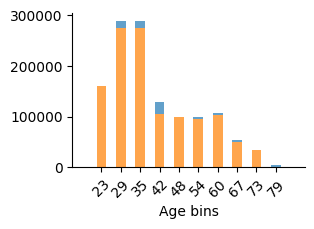

In [10]:
from ciim.src.common import palette_gender, surrogate_names
fig, ax = plt.subplots(1, 1, figsize=(3, 2), sharey=False)

df = adata.obs.copy()
df['sex'] = df['sex'].apply(lambda name: {'F':'Female', 'M':'Male'}.get(name, name))

# Count occurrences of each sex within each age group
df_count = df.groupby(['age', 'sex']).size().reset_index(name='count')

# Pivot data for stacking
df_pivot = df_count.pivot(index='age', columns='sex', values='count').fillna(0)

# Plot stacked bar chart
df_pivot['binned'] = pd.cut(pd.to_numeric(df_pivot.index, errors='coerce'), bins=10)  
df_binned = df_pivot.groupby('binned').sum() 
df_binned.plot(kind='bar', stacked=True, ax=ax, color=palette_gender, alpha=0.7)


ax.set_xlabel("Age bins")
# ax.set_ylabel("Sample (donor-age)" if i == 0 else "")  
# ax.set_title(surrogate_names[dataset], pad=15)
bin_midpoints = [int(interval.mid) for interval in df_binned.index.categories]
ax.set_xticklabels(bin_midpoints)

# Set x-axis ticks
# ax.set_xticks(bin_midpoints)
# Adjust xticks to show fewer labels
# xtick_labels = [int(float(label.get_text())) for label in ]
# step = max(1, len(xtick_labels) // 5)  # Show ~5 evenly spaced labels
# ax.set_xticks(range(0, len(xtick_labels), step))
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
x_min, x_max = ax.get_xlim()
ax.set_xlim(x_min - 1, x_max + 1) 
ax.get_legend().remove()
# plt.title('Cohort 3')

In [3]:
adata.obs.groupby('ct_major_published').size()

ct_major_published
B cell                             151570
lymphocyte                           8265
natural killer cell                 92554
CD4-positive, alpha-beta T cell    380477
CD8-positive, alpha-beta T cell    248927
plasmacytoid dendritic cell          5233
classical monocyte                 307429
non-classical monocyte              48800
plasmablast                          1411
conventional dendritic cell         18203
progenitor cell                       807
dtype: int64

In [4]:
adata.obs.groupby('sex').size()

sex
F    1195323
M      68353
dtype: int64

In [5]:
adata.obs.groupby('race').size()

race
European                      738773
Asian                         503999
Hispanic or Latin American      7686
African American               13218
dtype: int64

In [6]:
adata.obs.groupby('disease').size()

disease
systemic lupus erythematosus    777258
normal                          486418
dtype: int64

In [15]:
adata.obs['disease_state'] = adata.obs['disease_state'].astype(str)
adata.obs['donor_id'] = adata.obs['donor_id'].astype(str)
adata.obs.groupby(['disease_state'])['donor_id'].nunique()

disease_state
flare       19
managed    146
na          99
treated     10
Name: donor_id, dtype: int64